# 07 - Train Temporal CNN and Optional LSTM

This notebook turns the daily grid table into temporal sequences. Each sample uses the previous `SEQUENCE_LENGTH` days for one grid cell to predict whether that grid cell has at least one fire detection in the next 7 days.

The recommended first deep model is a Temporal CNN because it is faster and easier to debug than an LSTM. The LSTM section is optional.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# Edit this path to the location where you uploaded the project folder in Google Drive.
PROJECT_DIR = "/content/drive/MyDrive/fire-risk-project"
PROJECT_DIR = Path(PROJECT_DIR)

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUTS_DIR = PROJECT_DIR / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
MODELS_DIR = OUTPUTS_DIR / "models"
REPORTS_DIR = OUTPUTS_DIR / "reports"

for path in [FIGURES_DIR, MODELS_DIR, REPORTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

FILTERED_DATASET_PATH = PROCESSED_DIR / "fire_risk_dataset_2023_filtered.csv"
FULL_DATASET_PATH = PROCESSED_DIR / "fire_risk_dataset_2023_ndvi_firms.csv"
DATASET_PATH = FILTERED_DATASET_PATH if FILTERED_DATASET_PATH.exists() else FULL_DATASET_PATH

CNN_MODEL_PATH = MODELS_DIR / "temporal_cnn_fire_risk_2023.keras"
LSTM_MODEL_PATH = MODELS_DIR / "lstm_fire_risk_2023.keras"
SCALER_PATH = MODELS_DIR / "temporal_feature_scaler_2023.joblib"
CNN_PREDICTIONS_PATH = REPORTS_DIR / "test_predictions_2023_temporal_cnn.csv"
LSTM_PREDICTIONS_PATH = REPORTS_DIR / "test_predictions_2023_lstm.csv"
CNN_HISTORY_PATH = REPORTS_DIR / "temporal_cnn_training_history.csv"
TEMPORAL_METRICS_PATH = REPORTS_DIR / "temporal_model_metrics_2023.csv"
TEMPORAL_PR_PATH = FIGURES_DIR / "temporal_cnn_precision_recall.png"

print("Using dataset:", DATASET_PATH)


Mounted at /content/drive
Using dataset: /content/drive/MyDrive/fire-risk-project/data/processed/fire_risk_dataset_2023_filtered.csv


In [ ]:
# Optional: uncomment in Colab only if TensorFlow is missing.
# %pip install tensorflow


In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except ImportError as exc:
    raise ImportError("TensorFlow is required for this notebook. In Colab, run the optional install cell above.") from exc

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


## Configuration

`NEGATIVE_TO_POSITIVE_RATIO` controls memory and class balance. The model keeps all positive training sequences and samples a fixed number of negative sequences. Test evaluation remains chronological and uses all available test sequences.


In [3]:
SEQUENCE_LENGTH = 30
NEGATIVE_TO_POSITIVE_RATIO = 5
RANDOM_STATE = 42
VALIDATION_START = pd.Timestamp("2023-08-01")
TEST_START = pd.Timestamp("2023-10-01")

BASE_FEATURES = [
    "ndvi",
    "ndvi_change_16d",
    "fire_count_lag_1d",
    "fire_count_past_7d",
    "fire_count_past_30d",
]
TARGET = "fire_risk_label"


## Load Dataset And Add Cyclical Calendar Features

Calendar features are encoded with sine and cosine terms so the model understands seasonality without treating December and January as far apart.


In [4]:
df = pd.read_csv(DATASET_PATH)
df["date"] = pd.to_datetime(df["date"])
df["grid_id"] = df["grid_id"].astype(int)
df = df.sort_values(["grid_id", "date"]).copy()

df["dayofyear_sin"] = np.sin(2 * np.pi * df["dayofyear"] / 365.25)
df["dayofyear_cos"] = np.cos(2 * np.pi * df["dayofyear"] / 365.25)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

FEATURES = BASE_FEATURES + ["dayofyear_sin", "dayofyear_cos", "month_sin", "month_cos"]
df = df.dropna(subset=FEATURES + [TARGET]).copy()
df[TARGET] = df[TARGET].astype(int)

print(df.shape)
print(df["date"].min(), df["date"].max())
print(df[TARGET].value_counts(normalize=True))
display(df.head())


(997746, 18)
2023-01-01 00:00:00 2023-12-24 00:00:00
fire_risk_label
0    0.989843
1    0.010157
Name: proportion, dtype: float64


,grid_id,date,fire_count,ndvi,fire_next_7d_count,fire_count_next_7d,fire_risk_label,month,dayofyear,fire_count_lag_1d,fire_count_past_7d,fire_count_past_30d,ndvi_lag_16d,ndvi_change_16d,dayofyear_sin,dayofyear_cos,month_sin,month_cos
0,2,2023-01-01,0,0.081758,0.0,0.0,0,1,1,0.0,0.0,0.0,0.081758,0.0,0.017202,0.999852,0.5,0.866025
1,2,2023-01-02,0,0.081758,0.0,0.0,0,1,2,0.0,0.0,0.0,0.081758,0.0,0.034398,0.999408,0.5,0.866025
2,2,2023-01-03,0,0.081758,0.0,0.0,0,1,3,0.0,0.0,0.0,0.081758,0.0,0.051584,0.998669,0.5,0.866025
3,2,2023-01-04,0,0.081758,0.0,0.0,0,1,4,0.0,0.0,0.0,0.081758,0.0,0.068755,0.997634,0.5,0.866025
4,2,2023-01-05,0,0.081758,0.0,0.0,0,1,5,0.0,0.0,0.0,0.081758,0.0,0.085906,0.996303,0.5,0.866025


## Scale Features Without Test Leakage

The scaler is fit only on the core training period before the validation start date.


In [5]:
fit_mask = df["date"] < VALIDATION_START
scaler = StandardScaler()
scaler.fit(df.loc[fit_mask, FEATURES])

df_scaled = df.copy()
df_scaled[FEATURES] = scaler.transform(df_scaled[FEATURES]).astype("float32")
joblib.dump(scaler, SCALER_PATH)
print("Saved scaler:", SCALER_PATH)


Saved scaler: /content/drive/MyDrive/fire-risk-project/outputs/models/temporal_feature_scaler_2023.joblib


## Build Sequence Index

This creates lightweight sequence metadata first. Actual 3D arrays are materialized only after train/validation/test splitting and negative sampling.


In [6]:
def build_group_arrays(frame, features, target):
    groups = {}
    records = []

    for grid_id, group in frame.groupby("grid_id", sort=False):
        group = group.sort_values("date").reset_index(drop=True)
        if len(group) < SEQUENCE_LENGTH:
            continue

        groups[int(grid_id)] = {
            "X": group[features].to_numpy(dtype="float32"),
            "y": group[target].to_numpy(dtype="int8"),
            "date": group["date"].to_numpy(),
        }

        for end_pos in range(SEQUENCE_LENGTH - 1, len(group)):
            records.append(
                {
                    "grid_id": int(grid_id),
                    "end_pos": int(end_pos),
                    "end_date": group.loc[end_pos, "date"],
                    "label": int(group.loc[end_pos, target]),
                }
            )

    index_df = pd.DataFrame(records)
    return groups, index_df


groups, sequence_index = build_group_arrays(df_scaled, FEATURES, TARGET)
print("Groups:", len(groups))
print("Sequence candidates:", sequence_index.shape)
print(sequence_index["label"].value_counts(normalize=True))
display(sequence_index.head())


Groups: 2787
Sequence candidates: (916923, 4)
label
0    0.989653
1    0.010347
Name: proportion, dtype: float64


,grid_id,end_pos,end_date,label
0,2,29,2023-01-30,0
1,2,30,2023-01-31,0
2,2,31,2023-02-01,0
3,2,32,2023-02-02,0
4,2,33,2023-02-03,0


In [7]:
train_index = sequence_index[sequence_index["end_date"] < VALIDATION_START].copy()
val_index = sequence_index[
    (sequence_index["end_date"] >= VALIDATION_START)
    & (sequence_index["end_date"] < TEST_START)
].copy()
test_index = sequence_index[sequence_index["end_date"] >= TEST_START].copy()

rng = np.random.default_rng(RANDOM_STATE)
train_pos = train_index[train_index["label"] == 1]
train_neg = train_index[train_index["label"] == 0]
if train_pos.empty:
    raise ValueError("No positive training sequences found. Loosen the spatial filter or use more years of data.")

n_neg = min(len(train_neg), max(len(train_pos) * NEGATIVE_TO_POSITIVE_RATIO, 1))
sampled_neg_idx = rng.choice(train_neg.index.to_numpy(), size=n_neg, replace=False)
train_sampled = pd.concat([train_pos, train_neg.loc[sampled_neg_idx]], axis=0).sample(frac=1, random_state=RANDOM_STATE)

print("Train full:")
print(train_index["label"].value_counts())
print("Train sampled:")
print(train_sampled["label"].value_counts())
print("Validation:")
print(val_index["label"].value_counts())
print("Test:")
print(test_index["label"].value_counts())


Train full:
label
0    504828
1      5193
Name: count, dtype: int64
Train sampled:
label
0    25965
1     5193
Name: count, dtype: int64
Validation:
label
0    168155
1      1852
Name: count, dtype: int64
Test:
label
0    234453
1      2442
Name: count, dtype: int64


In [8]:
def materialize_sequences(index_df, groups, sequence_length, n_features):
    X = np.empty((len(index_df), sequence_length, n_features), dtype="float32")
    y = np.empty((len(index_df),), dtype="int8")

    for row_i, row in enumerate(index_df.itertuples(index=False)):
        group = groups[int(row.grid_id)]
        end_pos = int(row.end_pos)
        start_pos = end_pos - sequence_length + 1
        X[row_i] = group["X"][start_pos : end_pos + 1]
        y[row_i] = int(row.label)

    return X, y


X_train, y_train = materialize_sequences(train_sampled, groups, SEQUENCE_LENGTH, len(FEATURES))
X_val, y_val = materialize_sequences(val_index, groups, SEQUENCE_LENGTH, len(FEATURES))
X_test, y_test = materialize_sequences(test_index, groups, SEQUENCE_LENGTH, len(FEATURES))

print("X_train:", X_train.shape, y_train.shape)
print("X_val:", X_val.shape, y_val.shape)
print("X_test:", X_test.shape, y_test.shape)


X_train: (31158, 30, 9) (31158,)
X_val: (170007, 30, 9) (170007,)
X_test: (236895, 30, 9) (236895,)


## Temporal CNN

This model looks for short temporal patterns in the previous days. It is a good first temporal model because it trains faster than LSTM on long tabular sequences.


In [9]:
def build_temporal_cnn(input_shape):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv1D(64, kernel_size=5, padding="causal", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.20)(x)
    x = layers.Conv1D(64, kernel_size=3, padding="causal", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.20)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.AUC(curve="ROC", name="roc_auc"),
            keras.metrics.AUC(curve="PR", name="pr_auc"),
        ],
    )
    return model


cnn = build_temporal_cnn((SEQUENCE_LENGTH, len(FEATURES)))
cnn.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 30, 64)         │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,033 (78.25 KB)

 Trainable params: 19,777 (77.25 KB)

 Non-trainable params: 256 (1.00 KB)

In [10]:
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {int(cls): float(weight) for cls, weight in zip(classes, weights)}
print("class_weight:", class_weight)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_pr_auc", mode="max", factor=0.5, patience=2, min_lr=1e-5),
]

history = cnn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=512,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)

pd.DataFrame(history.history).to_csv(CNN_HISTORY_PATH, index=False)
cnn.save(CNN_MODEL_PATH)
print("Saved history:", CNN_HISTORY_PATH)
print("Saved model:", CNN_MODEL_PATH)


class_weight: {0: 0.6, 1: 3.0}
Epoch 1/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 17s 215ms/step - loss: 0.3297 - pr_auc: 0.7765 - roc_auc: 0.9332 - val_loss: 0.5926 - val_pr_auc: 0.1919 - val_roc_auc: 0.9363 - learning_rate: 0.0010
Epoch 2/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 17s 288ms/step - loss: 0.2868 - pr_auc: 0.8224 - roc_auc: 0.9481 - val_loss: 0.5120 - val_pr_auc: 0.1981 - val_roc_auc: 0.9367 - learning_rate: 0.0010
Epoch 3/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 13s 209ms/step - loss: 0.2801 - pr_auc: 0.8273 - roc_auc: 0.9501 - val_loss: 0.3895 - val_pr_auc: 0.2050 - val_roc_auc: 0.9341 - learning_rate: 0.0010
Epoch 4/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 13s 215ms/step - loss: 0.2725 - pr_auc: 0.8371 - roc_auc: 0.9527 - val_loss: 0.4738 - val_pr_auc: 0.2230 - val_roc_auc: 0.9307 - learning_rate: 0.0010
Epoch 5/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 23s 255ms/step - loss: 0.2718 - pr_auc: 0.8383 - roc_auc: 0.9532 - val_loss: 0.2672 - val_pr_auc: 0.2535 - val_roc_auc: 0.9342 - learning_rate: 0.0010
Epoch 6/25
61/61 ━━━━━━━

## Choose Threshold On Validation Set

The threshold is chosen on validation data only, then applied once to the test period.


In [11]:
val_proba = cnn.predict(X_val, batch_size=2048).ravel()
precision, recall, pr_thresholds = precision_recall_curve(y_val, val_proba)
f1_scores = 2 * precision * recall / np.maximum(precision + recall, 1e-12)
best_idx = int(np.nanargmax(f1_scores[:-1])) if len(pr_thresholds) else 0
best_threshold = float(pr_thresholds[best_idx]) if len(pr_thresholds) else 0.5

print("Validation PR AUC:", average_precision_score(y_val, val_proba))
print("Best validation F1 threshold:", best_threshold)
print("Validation precision:", precision[best_idx])
print("Validation recall:", recall[best_idx])
print("Validation F1:", f1_scores[best_idx])


84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step
Validation PR AUC: 0.30281380941329894
Best validation F1 threshold: 0.9696123003959656
Validation precision: 0.4875886524822695
Validation recall: 0.296976241900648
Validation F1: 0.36912751677852346


In [12]:
test_proba = cnn.predict(X_test, batch_size=2048).ravel()
test_pred = (test_proba >= best_threshold).astype(int)

print(classification_report(y_test, test_pred, zero_division=0))
print("Confusion matrix:")
print(confusion_matrix(y_test, test_pred, labels=[0, 1]))
print("Test ROC AUC:", roc_auc_score(y_test, test_proba) if len(np.unique(y_test)) == 2 else np.nan)
print("Test PR AUC:", average_precision_score(y_test, test_proba) if len(np.unique(y_test)) == 2 else np.nan)

cnn_predictions = test_index[["grid_id", "end_date", "label"]].copy()
cnn_predictions = cnn_predictions.rename(columns={"end_date": "date", "label": "fire_risk_label"})
cnn_predictions["pred_probability"] = test_proba
cnn_predictions["pred_label"] = test_pred
cnn_predictions["threshold"] = best_threshold
cnn_predictions.to_csv(CNN_PREDICTIONS_PATH, index=False)
print("Saved:", CNN_PREDICTIONS_PATH)


116/116 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    234453
           1       0.42      0.33      0.37      2442

    accuracy                           0.99    236895
   macro avg       0.71      0.66      0.68    236895
weighted avg       0.99      0.99      0.99    236895

Confusion matrix:
[[233359   1094]
 [  1635    807]]
Test ROC AUC: 0.9063039455740766
Test PR AUC: 0.33128584213524803
Saved: /content/drive/MyDrive/fire-risk-project/outputs/reports/test_predictions_2023_temporal_cnn.csv


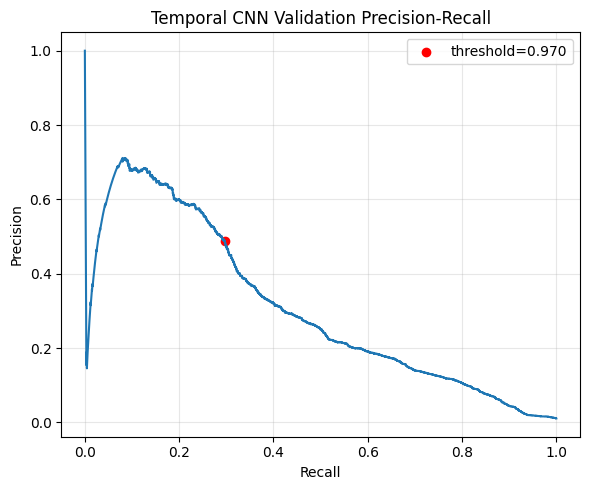

Saved: /content/drive/MyDrive/fire-risk-project/outputs/figures/temporal_cnn_precision_recall.png


In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall, precision)
ax.scatter(recall[best_idx], precision[best_idx], color="red", label=f"threshold={best_threshold:.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Temporal CNN Validation Precision-Recall")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(TEMPORAL_PR_PATH, dpi=180)
plt.show()
print("Saved:", TEMPORAL_PR_PATH)


## Optional LSTM

Run this only after the Temporal CNN is stable. LSTMs can be slower and are not automatically better for this dataset.


In [14]:
RUN_LSTM = False

def build_lstm(input_shape):
    inputs = keras.Input(shape=input_shape)
    x = layers.LSTM(64, dropout=0.20, recurrent_dropout=0.0)(inputs)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.20)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.AUC(curve="ROC", name="roc_auc"),
            keras.metrics.AUC(curve="PR", name="pr_auc"),
        ],
    )
    return model


if RUN_LSTM:
    lstm = build_lstm((SEQUENCE_LENGTH, len(FEATURES)))
    lstm.summary()
    lstm.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=25,
        batch_size=512,
        class_weight=class_weight,
        callbacks=callbacks,
        verbose=1,
    )
    lstm.save(LSTM_MODEL_PATH)
    lstm_proba = lstm.predict(X_test, batch_size=2048).ravel()
    lstm_pred = (lstm_proba >= best_threshold).astype(int)
    print(classification_report(y_test, lstm_pred, zero_division=0))
    lstm_predictions = test_index[["grid_id", "end_date", "label"]].copy()
    lstm_predictions = lstm_predictions.rename(columns={"end_date": "date", "label": "fire_risk_label"})
    lstm_predictions["pred_probability"] = lstm_proba
    lstm_predictions["pred_label"] = lstm_pred
    lstm_predictions["threshold"] = best_threshold
    lstm_predictions.to_csv(LSTM_PREDICTIONS_PATH, index=False)
    print("Saved:", LSTM_MODEL_PATH)
    print("Saved:", LSTM_PREDICTIONS_PATH)


In [15]:
metrics_rows = [
    {
        "model": "temporal_cnn",
        "sequence_length": SEQUENCE_LENGTH,
        "threshold": best_threshold,
        "test_roc_auc": roc_auc_score(y_test, test_proba) if len(np.unique(y_test)) == 2 else np.nan,
        "test_pr_auc": average_precision_score(y_test, test_proba) if len(np.unique(y_test)) == 2 else np.nan,
        "test_rows": len(y_test),
        "test_positive_rate": float(np.mean(y_test)),
    }
]
pd.DataFrame(metrics_rows).to_csv(TEMPORAL_METRICS_PATH, index=False)
print("Saved:", TEMPORAL_METRICS_PATH)
display(pd.DataFrame(metrics_rows))


Saved: /content/drive/MyDrive/fire-risk-project/outputs/reports/temporal_model_metrics_2023.csv


,model,sequence_length,threshold,test_roc_auc,test_pr_auc,test_rows,test_positive_rate
0,temporal_cnn,30,0.969612,0.906304,0.331286,236895,0.010308
